# Violent Crime Capstone

**Main question:** How well can socioeconomic factors predict violent crime rates?  
**Subquestion:** Which categories are the strongest predictors of violent crime?

This notebook cleans and merges:
- FBI violent crime data (2024)
- BLS county unemployment data (2024)
- ACS 5-year county income, poverty, and education data (2024 release)


## 1. Imports and setup

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

BASE_DIR = Path.cwd()
CLEAN_DATA = BASE_DIR / 'cleaned_data'
OUTPUTS = BASE_DIR / 'outputs'

CLEAN_DATA.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)


## 2. Load and clean FBI violent crime data

In [118]:
crime_file = BASE_DIR / 'CIUS_Table_10_Offenses_Known_to_Law_Enforcement_by_State_by_Metropolitan_and_Nonmetropolitan_Counties_2024.xlsx'

crime = pd.read_excel(crime_file, header=4)

crime.columns = (
    crime.columns.astype(str)
    .str.strip()
    .str.replace('\n', '_', regex=False)
    .str.replace(' ', '_', regex=False)
    .str.replace('/', '_', regex=False)
    .str.replace('-', '_', regex=False)
    .str.replace(r'[^A-Za-z0-9_]', '', regex=True)
    .str.replace(r'_+', '_', regex=True)
    .str.strip('_')
    .str.lower()
)

print(crime.columns.tolist())

crime = crime.rename(columns={
    'violent_crime1': 'violent_crime',
    'violent_crime_': 'violent_crime',
    'violentcrime': 'violent_crime',
    'murder_and_nonnegligent_manslaughter1': 'murder_and_nonnegligent_manslaughter',
    'murder_and_nonnegligent_manslaughter_': 'murder_and_nonnegligent_manslaughter',
    'aggravated_assault1': 'aggravated_assault',
    'aggravated_assault_': 'aggravated_assault',
    'property_crime1': 'property_crime',
    'property_crime_': 'property_crime',
    'motor_vehicle_theft1': 'motor_vehicle_theft',
    'motor_vehicle_theft_': 'motor_vehicle_theft',
    'larceny_theft1': 'larceny_theft',
    'arson1': 'arson'
})

# auto-fix likely variants if needed
rename_map = {}

for col in crime.columns:
    if 'violent' in col and 'violent_crime' not in crime.columns:
        rename_map[col] = 'violent_crime'
    elif 'murder' in col and 'manslaughter' in col and 'murder_and_nonnegligent_manslaughter' not in crime.columns:
        rename_map[col] = 'murder_and_nonnegligent_manslaughter'
    elif 'aggravated' in col and 'assault' in col and 'aggravated_assault' not in crime.columns:
        rename_map[col] = 'aggravated_assault'
    elif 'property' in col and 'crime' in col and 'property_crime' not in crime.columns:
        rename_map[col] = 'property_crime'
    elif 'motor' in col and 'vehicle' in col and 'theft' in col and 'motor_vehicle_theft' not in crime.columns:
        rename_map[col] = 'motor_vehicle_theft'
    elif 'larceny' in col and 'theft' in col and 'larceny_theft' not in crime.columns:
        rename_map[col] = 'larceny_theft'
    elif col.startswith('arson') and 'arson' not in crime.columns:
        rename_map[col] = 'arson'

crime = crime.rename(columns=rename_map)

print(crime.columns.tolist())

crime = crime.dropna(subset=['county', 'violent_crime']).copy()
crime['arson'] = crime['arson'].fillna(0)

crime_cols = [
    'violent_crime',
    'murder_and_nonnegligent_manslaughter',
    'rape',
    'robbery',
    'aggravated_assault',
    'property_crime',
    'burglary',
    'larceny_theft',
    'motor_vehicle_theft',
    'arson'
]

crime[crime_cols] = crime[crime_cols].apply(pd.to_numeric, errors='coerce')
crime[crime_cols] = crime[crime_cols].fillna(0).astype(int)
crime['year'] = 2024

crime.info()
crime.head()

['state', 'metropolitan_nonmetropolitan', 'county', 'violent_crime', 'murder_and_nonnegligent_manslaughter', 'rape', 'robbery', 'aggravated_assault', 'property_crime', 'burglary', 'larceny_theft', 'motor_vehicle_theft', 'arson1']
['state', 'metropolitan_nonmetropolitan', 'county', 'violent_crime', 'murder_and_nonnegligent_manslaughter', 'rape', 'robbery', 'aggravated_assault', 'property_crime', 'burglary', 'larceny_theft', 'motor_vehicle_theft', 'arson']
<class 'pandas.core.frame.DataFrame'>
Index: 2444 entries, 0 to 2443
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   state                                 2444 non-null   object
 1   metropolitan_nonmetropolitan          2444 non-null   object
 2   county                                2444 non-null   object
 3   violent_crime                         2444 non-null   int64 
 4   murder_and_nonnegligent_manslaughter  

,state,metropolitan_nonmetropolitan,county,violent_crime,murder_and_nonnegligent_manslaughter,rape,robbery,aggravated_assault,property_crime,burglary,larceny_theft,motor_vehicle_theft,arson,year
0,ALABAMA,Metropolitan County,Autauga,54,1,7,0,46,221,46,143,32,1,2024
1,ALABAMA,Metropolitan County,Baldwin,137,0,4,0,133,170,23,142,5,2,2024
2,ALABAMA,Metropolitan County,Bibb,34,0,5,0,29,78,26,43,9,0,2024
3,ALABAMA,Metropolitan County,Blount,82,1,18,2,61,298,66,180,52,2,2024
4,ALABAMA,Metropolitan County,Calhoun,238,2,5,0,231,192,48,144,0,8,2024


In [119]:
crime = crime.dropna(subset=['county', 'violent_crime']).copy()
crime['arson'] = crime['arson'].fillna(0)

crime_cols = [
    'violent_crime',
    'murder_and_nonnegligent_manslaughter',
    'rape',
    'robbery',
    'aggravated_assault',
    'property_crime',
    'burglary',
    'larceny_theft',
    'motor_vehicle_theft',
    'arson'
]

crime[crime_cols] = crime[crime_cols].apply(pd.to_numeric, errors='coerce')
crime[crime_cols] = crime[crime_cols].astype(int)
crime['year'] = 2024

crime.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2444 entries, 0 to 2443
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   state                                 2444 non-null   object
 1   metropolitan_nonmetropolitan          2444 non-null   object
 2   county                                2444 non-null   object
 3   violent_crime                         2444 non-null   int64 
 4   murder_and_nonnegligent_manslaughter  2444 non-null   int64 
 5   rape                                  2444 non-null   int64 
 6   robbery                               2444 non-null   int64 
 7   aggravated_assault                    2444 non-null   int64 
 8   property_crime                        2444 non-null   int64 
 9   burglary                              2444 non-null   int64 
 10  larceny_theft                         2444 non-null   int64 
 11  motor_vehicle_theft                

In [120]:
state_to_abbr = {
    'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR',
    'CALIFORNIA': 'CA', 'COLORADO': 'CO', 'CONNECTICUT': 'CT', 'DELAWARE': 'DE',
    'FLORIDA': 'FL', 'GEORGIA': 'GA', 'HAWAII': 'HI', 'IDAHO': 'ID',
    'ILLINOIS': 'IL', 'INDIANA': 'IN', 'IOWA': 'IA', 'KANSAS': 'KS',
    'KENTUCKY': 'KY', 'LOUISIANA': 'LA', 'MAINE': 'ME', 'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI', 'MINNESOTA': 'MN', 'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO', 'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH', 'NEW JERSEY': 'NJ', 'NEW MEXICO': 'NM', 'NEW YORK': 'NY',
    'NORTH CAROLINA': 'NC', 'NORTH DAKOTA': 'ND', 'OHIO': 'OH', 'OKLAHOMA': 'OK',
    'OREGON': 'OR', 'PENNSYLVANIA': 'PA', 'RHODE ISLAND': 'RI', 'SOUTH CAROLINA': 'SC',
    'SOUTH DAKOTA': 'SD', 'TENNESSEE': 'TN', 'TEXAS': 'TX', 'UTAH': 'UT',
    'VERMONT': 'VT', 'VIRGINIA': 'VA', 'WASHINGTON': 'WA', 'WEST VIRGINIA': 'WV',
    'WISCONSIN': 'WI', 'WYOMING': 'WY', 'DISTRICT OF COLUMBIA': 'DC'
}


def clean_county_name(series):
    return (
        series.astype(str)
        .str.strip()
        .str.upper()
        .str.replace(' COUNTY', '', regex=False)
        .str.replace(' PARISH', '', regex=False)
        .str.replace(' BOROUGH', '', regex=False)
        .str.replace(' CENSUS AREA', '', regex=False)
        .str.replace(' MUNICIPALITY', '', regex=False)
        .str.replace(' CITY AND BOROUGH OF ', '', regex=False)
        .str.replace(' CITY OF ', '', regex=False)
        .str.replace(' ST.', 'SAINT', regex=False)
        .str.replace(' ST ', 'SAINT ', regex=False)
        .str.replace('.', '', regex=False)
    )

crime['state'] = (
    crime['state']
    .astype(str)
    .str.upper()
    .str.strip()
    .str.replace(r'[^A-Z ]', '', regex=True)
    .str.strip()
)

crime = crime[
    ~crime['county'].astype(str).str.contains(
        'Police Department|Sheriff|Department of Public Safety|Marshal|Township|Village|City of|Public Safety',
        case=False,
        na=False
    )
].copy()

crime['state_abbr'] = crime['state'].map(state_to_abbr)
crime['county_clean'] = clean_county_name(crime['county'])

crime['county_clean'] = crime['county_clean'].replace({
    'DEWITT': 'DE WITT',
    'LA SALLE': 'LASALLE',
    'ANACONDA-DEER LODGE': 'ANACONDA DEER LODGE',
    'BUTTE-SILVER BOW': 'BUTTE SILVER BOW',
    'HARTSVILLE/TROUSDALE': 'TROUSDALE'
})

crime[['state', 'state_abbr', 'county', 'county_clean']].head()

,state,state_abbr,county,county_clean
0,ALABAMA,AL,Autauga,AUTAUGA
1,ALABAMA,AL,Baldwin,BALDWIN
2,ALABAMA,AL,Bibb,BIBB
3,ALABAMA,AL,Blount,BLOUNT
4,ALABAMA,AL,Calhoun,CALHOUN


In [121]:
crime.to_csv(CLEAN_DATA / 'crime_cleaned.csv', index=False)

## 3. Load and clean BLS county unemployment data

In [122]:
bls_file = BASE_DIR / 'laucnty24.xlsx'
bls = pd.read_excel(bls_file, header=1)

bls.columns = (
    bls.columns.astype(str)
    .str.strip()
    .str.replace('\\n', '_', regex=False)
    .str.replace(' ', '_', regex=False)
    .str.replace('/', '_', regex=False)
    .str.replace('-', '_', regex=False)
    .str.replace('%', 'pct', regex=False)
    .str.replace(r'[^A-Za-z0-9_]', '', regex=True)
    .str.lower()
)

bls = bls.rename(columns={
    'county_name_state_abbreviation': 'county_name',
    'unemployment_rate_pct': 'unemployment_rate'
})

bls = bls.dropna(subset=['state_fips_code', 'county_fips_code']).copy()
bls['state_fips_code'] = bls['state_fips_code'].astype(int).astype(str).str.zfill(2)
bls['county_fips_code'] = bls['county_fips_code'].astype(int).astype(str).str.zfill(3)
bls['fips'] = bls['state_fips_code'] + bls['county_fips_code']

num_cols = ['year', 'labor_force', 'employed', 'unemployed', 'unemployment_rate']
bls[num_cols] = bls[num_cols].apply(pd.to_numeric, errors='coerce')

bls[['county_clean', 'state_abbr']] = bls['county_name'].str.split(',', n=1, expand=True)
bls['county_clean'] = clean_county_name(bls['county_clean'])
bls['state_abbr'] = bls['state_abbr'].str.strip()

bls = bls[[
    'fips', 'county_name', 'state_abbr', 'county_clean', 'year',
    'labor_force', 'employed', 'unemployed', 'unemployment_rate'
]]

bls.head()

,fips,county_name,state_abbr,county_clean,year,labor_force,employed,unemployed,unemployment_rate
0,01001,"Autauga County, AL",AL,AUTAUGA,"2,024.000","28,467.000","27,702.000",765.000,2.700
1,01003,"Baldwin County, AL",AL,BALDWIN,"2,024.000","116,653.000","113,448.000","3,205.000",2.700
2,01005,"Barbour County, AL",AL,BARBOUR,"2,024.000","8,674.000","8,302.000",372.000,4.300
3,01007,"Bibb County, AL",AL,BIBB,"2,024.000","8,710.000","8,446.000",264.000,3.000
4,01009,"Blount County, AL",AL,BLOUNT,"2,024.000","26,922.000","26,204.000",718.000,2.700


## 4. Merge FBI and BLS data

In [123]:
merged = crime.merge(
    bls,
    on=['state_abbr', 'county_clean', 'year'],
    how='left',
    suffixes=('_crime', '_bls')
)

print('Missing unemployment_rate values:', merged['unemployment_rate'].isna().sum())
merged[merged['unemployment_rate'].isna()][['state', 'county']].drop_duplicates().head(20)

Missing unemployment_rate values: 4


,state,county
1182,MONTANA,Anaconda-Deer Lodge
1186,MONTANA,Butte-Silver Bow
1996,TEXAS,DeWitt
2046,TEXAS,La Salle


In [124]:
merged.to_csv(CLEAN_DATA / 'crime_bls_merged.csv', index=False)

## 5. Pull ACS income data and merge

In [125]:
acs_income_url = 'https://api.census.gov/data/2024/acs/acs5?get=NAME,B19013_001E&for=county:*'

acs_income = pd.read_json(acs_income_url)
acs_income.columns = acs_income.iloc[0]
acs_income = acs_income[1:].copy()

acs_income = acs_income.rename(columns={
    'NAME': 'county_name',
    'B19013_001E': 'median_household_income',
    'state': 'state_fips',
    'county': 'county_fips'
})

acs_income['state_fips'] = acs_income['state_fips'].astype(str).str.zfill(2)
acs_income['county_fips'] = acs_income['county_fips'].astype(str).str.zfill(3)
acs_income['fips'] = acs_income['state_fips'] + acs_income['county_fips']
acs_income['median_household_income'] = pd.to_numeric(acs_income['median_household_income'], errors='coerce')

acs_income = acs_income[['fips', 'county_name', 'median_household_income']]
acs_income.head()

,fips,county_name,median_household_income
1,01001,"Autauga County, Alabama",72481
2,01003,"Baldwin County, Alabama",78775
3,01005,"Barbour County, Alabama",46042
4,01007,"Bibb County, Alabama",52541
5,01009,"Blount County, Alabama",64190


In [126]:
merged = merged.drop(columns=['median_household_income'], errors='ignore')

merged = merged.merge(
    acs_income[['fips', 'median_household_income']],
    on='fips',
    how='left'
)

print('Missing median household income values:', merged['median_household_income'].isna().sum())

Missing median household income values: 4


## 6. Pull ACS poverty data and merge

In [127]:
acs_poverty_url = 'https://api.census.gov/data/2024/acs/acs5/subject?get=NAME,S1701_C03_001E&for=county:*'

acs_poverty = pd.read_json(acs_poverty_url)
acs_poverty.columns = acs_poverty.iloc[0]
acs_poverty = acs_poverty[1:].copy()

acs_poverty = acs_poverty.rename(columns={
    'NAME': 'county_name',
    'S1701_C03_001E': 'poverty_rate',
    'state': 'state_fips',
    'county': 'county_fips'
})

acs_poverty['state_fips'] = acs_poverty['state_fips'].astype(str).str.zfill(2)
acs_poverty['county_fips'] = acs_poverty['county_fips'].astype(str).str.zfill(3)
acs_poverty['fips'] = acs_poverty['state_fips'] + acs_poverty['county_fips']
acs_poverty['poverty_rate'] = pd.to_numeric(acs_poverty['poverty_rate'], errors='coerce')

acs_poverty = acs_poverty[['fips', 'county_name', 'poverty_rate']]
acs_poverty.head()

,fips,county_name,poverty_rate
1,01001,"Autauga County, Alabama",11.300
2,01003,"Baldwin County, Alabama",10.100
3,01005,"Barbour County, Alabama",21.400
4,01007,"Bibb County, Alabama",22.500
5,01009,"Blount County, Alabama",12.900


In [128]:
merged = merged.drop(columns=['poverty_rate'], errors='ignore')

merged = merged.merge(
    acs_poverty[['fips', 'poverty_rate']],
    on='fips',
    how='left'
)

print('Missing poverty_rate values:', merged['poverty_rate'].isna().sum())

Missing poverty_rate values: 4


## 7. Pull ACS education data and merge

In [129]:
acs_education_url = 'https://api.census.gov/data/2024/acs/acs5/subject?get=NAME,S1501_C02_015E&for=county:*'

acs_education = pd.read_json(acs_education_url)
acs_education.columns = acs_education.iloc[0]
acs_education = acs_education[1:].copy()

acs_education = acs_education.rename(columns={
    'NAME': 'county_name',
    'S1501_C02_015E': 'bachelors_or_higher_pct',
    'state': 'state_fips',
    'county': 'county_fips'
})

acs_education['state_fips'] = acs_education['state_fips'].astype(str).str.zfill(2)
acs_education['county_fips'] = acs_education['county_fips'].astype(str).str.zfill(3)
acs_education['fips'] = acs_education['state_fips'] + acs_education['county_fips']
acs_education['bachelors_or_higher_pct'] = pd.to_numeric(acs_education['bachelors_or_higher_pct'], errors='coerce')

acs_education = acs_education[['fips', 'county_name', 'bachelors_or_higher_pct']]
acs_education.head()

,fips,county_name,bachelors_or_higher_pct
1,01001,"Autauga County, Alabama",29.100
2,01003,"Baldwin County, Alabama",33.700
3,01005,"Barbour County, Alabama",10.600
4,01007,"Bibb County, Alabama",11.700
5,01009,"Blount County, Alabama",15.800


In [130]:
acs_population_url = 'https://api.census.gov/data/2024/acs/acs5?get=NAME,B01003_001E&for=county:*'

acs_population = pd.read_json(acs_population_url)
acs_population.columns = acs_population.iloc[0]
acs_population = acs_population[1:].copy()

acs_population = acs_population.rename(columns={
    'NAME': 'county_name',
    'B01003_001E': 'population',
    'state': 'state_fips',
    'county': 'county_fips'
})

acs_population['state_fips'] = acs_population['state_fips'].astype(str).str.zfill(2)
acs_population['county_fips'] = acs_population['county_fips'].astype(str).str.zfill(3)
acs_population['fips'] = acs_population['state_fips'] + acs_population['county_fips']
acs_population['population'] = pd.to_numeric(acs_population['population'], errors='coerce')

acs_population = acs_population[['fips', 'county_name', 'population']]
acs_population.head()

,fips,county_name,population
1,01001,"Autauga County, Alabama",59947
2,01003,"Baldwin County, Alabama",246989
3,01005,"Barbour County, Alabama",24643
4,01007,"Bibb County, Alabama",22130
5,01009,"Blount County, Alabama",59518


In [131]:
merged = merged.drop(columns=['population'], errors='ignore')

merged = merged.merge(
    acs_population[['fips', 'population']],
    on='fips',
    how='left'
)

print('Missing population values:', merged['population'].isna().sum())

Missing population values: 4


In [132]:
merged = merged.drop(columns=['bachelors_or_higher_pct'], errors='ignore')

merged = merged.merge(
    acs_education[['fips', 'bachelors_or_higher_pct']],
    on='fips',
    how='left'
)

print('Missing bachelors_or_higher_pct values:', merged['bachelors_or_higher_pct'].isna().sum())
merged[merged['bachelors_or_higher_pct'].isna()][['state', 'county']].drop_duplicates()

Missing bachelors_or_higher_pct values: 4


,state,county
1182,MONTANA,Anaconda-Deer Lodge
1186,MONTANA,Butte-Silver Bow
1996,TEXAS,DeWitt
2046,TEXAS,La Salle


## 8. Final cleaned dataset

In [133]:
final_df = merged.dropna(subset=[
    'violent_crime',
    'unemployment_rate',
    'median_household_income',
    'poverty_rate',
    'bachelors_or_higher_pct',
    'population'
]).copy()

final_df = final_df[final_df['population'] > 0].copy()

final_df['violent_crime_rate'] = (
    final_df['violent_crime'] / final_df['population']
) * 100000

print('Merged shape:', merged.shape)
print('Final shape after dropping rows with missing modeling variables:', final_df.shape)

final_df[['state', 'county', 'violent_crime', 'population', 'violent_crime_rate']].head()

Merged shape: (2396, 26)
Final shape after dropping rows with missing modeling variables: (2392, 27)


,state,county,violent_crime,population,violent_crime_rate
0,ALABAMA,Autauga,54,"59,947.000",90.080
1,ALABAMA,Baldwin,137,"246,989.000",55.468
2,ALABAMA,Bibb,34,"22,130.000",153.638
3,ALABAMA,Blount,82,"59,518.000",137.773
4,ALABAMA,Calhoun,238,"116,090.000",205.013


In [134]:
final_df.to_csv(CLEAN_DATA / 'violent_crime_final_dataset.csv', index=False)
merged.to_csv(CLEAN_DATA / 'crime_bls_income_poverty_education_merged.csv', index=False)


## 10. Modeling: Linear Regression and Random Forest

We use two regression models to predict county-level violent crime counts from socioeconomic factors.  
Linear regression serves as a baseline, interpretable model that shows the direction and size of relationships between predictors and violent crime.  
Random forest regression is used as a more flexible model that can capture nonlinear relationships and interactions between predictors.  
Comparing both models allows us to balance interpretability and predictive performance while also identifying which socioeconomic variables are the strongest predictors of violent crime.

In [135]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [136]:
final_df['income_k'] = final_df['median_household_income'] / 1000

In [137]:
model_df = final_df.copy()

# log-transform target
model_df['log_violent_crime_rate'] = np.log1p(model_df['violent_crime_rate'])

# make dummy variables
model_df = pd.get_dummies(
    model_df,
    columns=['metropolitan_nonmetropolitan', 'state'],
    drop_first=True,
    dtype=int
)

base_features = [
    'unemployment_rate',
    'income_k',
    'poverty_rate',
    'bachelors_or_higher_pct'
]

# only keep numeric dummy columns, not raw text columns like state_abbr
dummy_features = [
    c for c in model_df.columns
    if (
        c.startswith('metropolitan_nonmetropolitan_') or c.startswith('state_')
    ) and pd.api.types.is_numeric_dtype(model_df[c])
]

features = base_features + dummy_features
target = 'log_violent_crime_rate'

model_df = model_df.dropna(subset=features + [target]).copy()

X = model_df[features]
y = model_df[target]

print("Any object columns in X?")
print(X.select_dtypes(include='object').columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Number of features:", len(features))

Any object columns in X?
[]
Training shape: (1913, 48)
Testing shape: (479, 48)
Number of features: 48


In [138]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = mean_squared_error(y_test, y_pred_lr) ** 0.5
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression Results")
print("R^2:", round(lr_r2, 4))
print("RMSE:", round(lr_rmse, 4))
print("MAE:", round(lr_mae, 4))

Linear Regression Results
R^2: 0.4058
RMSE: 1.0816
MAE: 0.7498


In [139]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df

,Feature,Coefficient
36,state_PENNSYLVANIA,-3.712
28,state_NEW JERSEY,-3.481
27,state_NEW HAMPSHIRE,-2.902
42,state_VERMONT,-1.938
37,state_SOUTH CAROLINA,1.372
16,state_KENTUCKY,-1.313
17,state_LOUISIANA,1.250
26,state_NEVADA,1.175
9,state_FLORIDA,1.076
6,state_ARKANSAS,0.980


In [140]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results")
print("R^2:", round(rf_r2, 4))
print("RMSE:", round(rf_rmse, 4))
print("MAE:", round(rf_mae, 4))

Random Forest Results
R^2: 0.3113
RMSE: 1.1644
MAE: 0.8229


In [141]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

rf_importance

,Feature,Importance
3,bachelors_or_higher_pct,0.170
1,income_k,0.143
2,poverty_rate,0.130
36,state_PENNSYLVANIA,0.124
0,unemployment_rate,0.108
28,state_NEW JERSEY,0.061
16,state_KENTUCKY,0.044
4,metropolitan_nonmetropolitan_Nonmetropolitan C...,0.014
40,state_TEXAS,0.014
27,state_NEW HAMPSHIRE,0.014


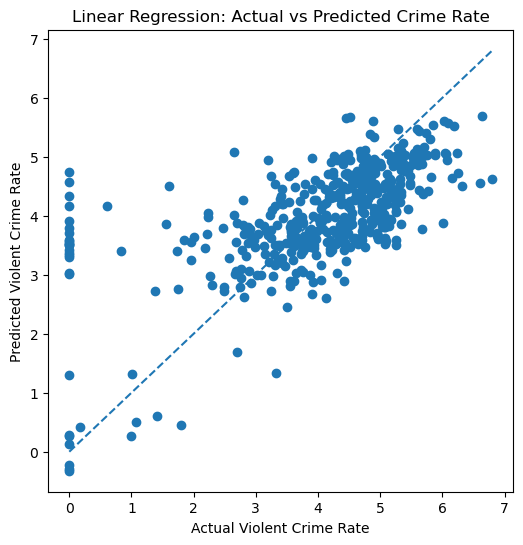

In [142]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("Actual Violent Crime Rate")
plt.ylabel("Predicted Violent Crime Rate")
plt.title("Linear Regression: Actual vs Predicted Crime Rate")
plt.show()

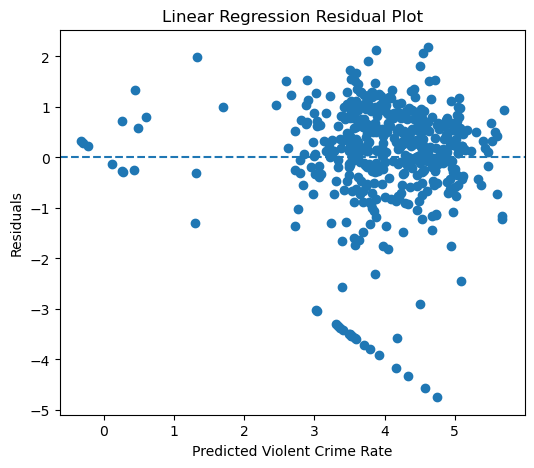

In [143]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(6, 5))
plt.scatter(y_pred_lr, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Violent Crime Rate")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.show()

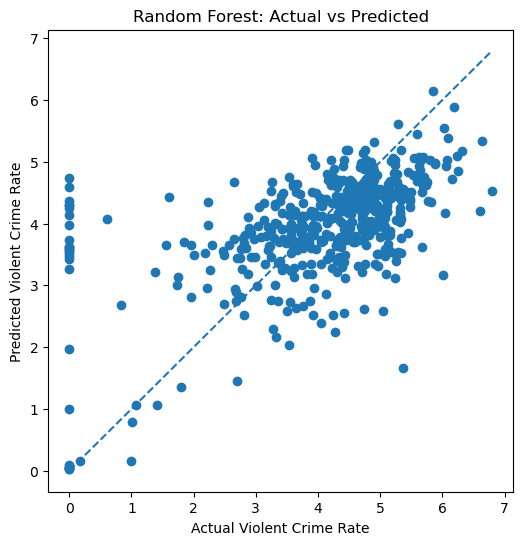

In [144]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel("Actual Violent Crime Rate")
plt.ylabel("Predicted Violent Crime Rate")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

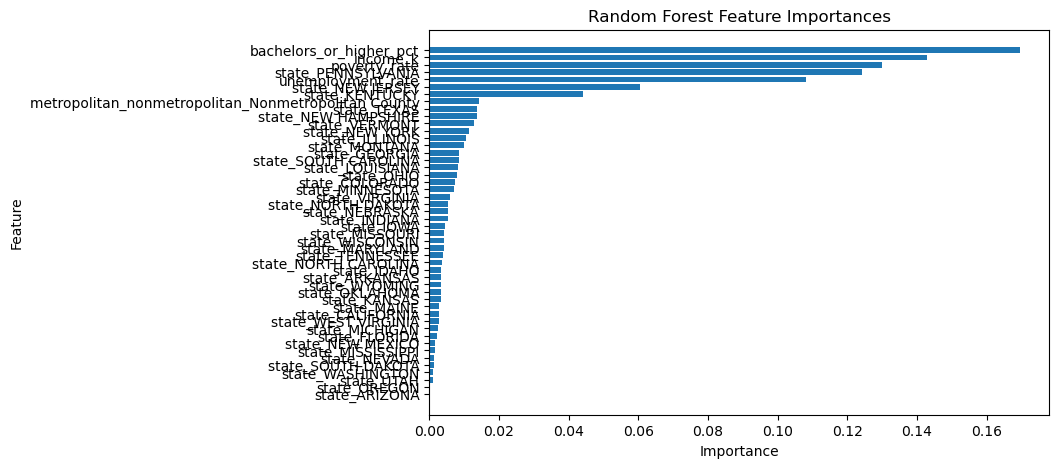

In [145]:
top_rf = rf_importance.sort_values('Importance')

plt.figure(figsize=(8, 5))
plt.barh(top_rf['Feature'], top_rf['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")
plt.show()

In [146]:
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R^2': [lr_r2, rf_r2],
    'RMSE': [lr_rmse, rf_rmse],
    'MAE': [lr_mae, rf_mae]
})

results_df

,Model,R^2,RMSE,MAE
0,Linear Regression,0.406,1.082,0.750
1,Random Forest,0.311,1.164,0.823


In [147]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df.head(15)

,Feature,Coefficient
36,state_PENNSYLVANIA,-3.712
28,state_NEW JERSEY,-3.481
27,state_NEW HAMPSHIRE,-2.902
42,state_VERMONT,-1.938
37,state_SOUTH CAROLINA,1.372
16,state_KENTUCKY,-1.313
17,state_LOUISIANA,1.250
26,state_NEVADA,1.175
9,state_FLORIDA,1.076
6,state_ARKANSAS,0.980


In [148]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

rf_importance.head(15)

,Feature,Importance
3,bachelors_or_higher_pct,0.170
1,income_k,0.143
2,poverty_rate,0.130
36,state_PENNSYLVANIA,0.124
0,unemployment_rate,0.108
28,state_NEW JERSEY,0.061
16,state_KENTUCKY,0.044
4,metropolitan_nonmetropolitan_Nonmetropolitan C...,0.014
40,state_TEXAS,0.014
27,state_NEW HAMPSHIRE,0.014


In [149]:
coef_df[~coef_df['Feature'].str.startswith('state_')]

,Feature,Coefficient
0,unemployment_rate,0.103
4,metropolitan_nonmetropolitan_Nonmetropolitan C...,-0.065
3,bachelors_or_higher_pct,-0.024
2,poverty_rate,-0.007
1,income_k,-0.000


In [150]:
rf_importance[~rf_importance['Feature'].str.startswith('state_')]

,Feature,Importance
3,bachelors_or_higher_pct,0.170
1,income_k,0.143
2,poverty_rate,0.130
0,unemployment_rate,0.108
4,metropolitan_nonmetropolitan_Nonmetropolitan C...,0.014


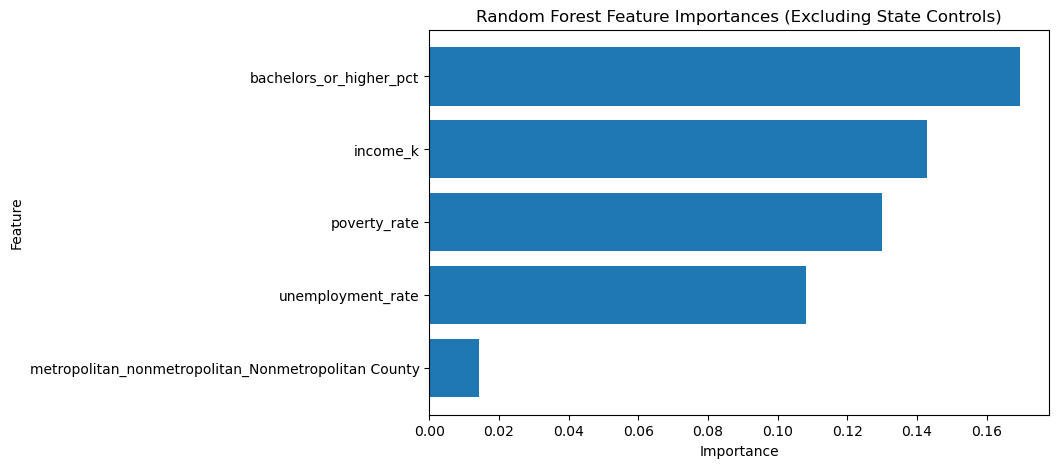

In [152]:
rf_importance_filtered = rf_importance[
    ~rf_importance['Feature'].str.startswith('state_')
].copy()

rf_importance_filtered

top_rf = rf_importance_filtered.sort_values('Importance')

plt.figure(figsize=(8,5))
plt.barh(top_rf['Feature'], top_rf['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances (Excluding State Controls)")
plt.show()